## Environment Setup and Hardware Check

In [45]:
import sys
import torch

print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Compiled Version: {torch.version.cuda}")
print(f"CUDA Available: {torch.cuda.is_available()}")

import logging
import os

# Suppress PyTorch compiler and Triton verbosity
os.environ["TORCH_LOGS"] = "-all"

for logger_name in ["torch", "torch._dynamo", "torch._inductor", "triton"]:
    logging.getLogger(logger_name).setLevel(logging.WARNING)

# Mute the filelock library explicitly
logging.getLogger("filelock").setLevel(logging.WARNING)

# Mute standard PyTorch and Triton loggers
logging.getLogger("torch").setLevel(logging.WARNING)
logging.getLogger("triton").setLevel(logging.WARNING)

# Stop third-party loggers from passing INFO messages to the root logger
for logger_name in ["filelock", "triton", "torch", "torch._inductor", "torch._dynamo"]:
    log = logging.getLogger(logger_name)
    log.setLevel(logging.WARNING)
    log.propagate = False

PyTorch Version: 2.0.1+cu117
CUDA Compiled Version: 11.7
CUDA Available: True


In [46]:
!nvidia-smi

Sat Aug 15 10:12:39 2026       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 470.199.02   Driver Version: 470.199.02   CUDA Version: 11.4     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  NVIDIA A100-SXM...  On   | 00000000:BD:00.0 Off |                   On |
| N/A   31C    P0    52W / 400W |                  N/A |     N/A      Default |
|                               |                      |              Enabled |
+-------------------------------+----------------------+----------------------+

+-----------------------------------------------------------------------------+
| MIG d

In [47]:
import sys
import random
import logging
import psutil
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Configure notebook logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    handlers=[logging.StreamHandler(sys.stdout)]
)

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    logging.info(f"All seeds set to {seed}")

seed_everything(42)

# Hardware Specifications
ram = psutil.virtual_memory()
logging.info(f"Total RAM: {ram.total / (1024**3):.2f} GB | Available: {ram.available / (1024**3):.2f} GB")
logging.info(f"Is CUDA available? {torch.cuda.is_available()}")
if torch.cuda.is_available():
    logging.info(f"GPU Device Name: {torch.cuda.get_device_name(0)}")

2026-08-15 10:12:40,134 | INFO | All seeds set to 42
2026-08-15 10:12:40,136 | INFO | Total RAM: 1007.68 GB | Available: 923.87 GB
2026-08-15 10:12:40,136 | INFO | Is CUDA available? True
2026-08-15 10:12:40,136 | INFO | GPU Device Name: NVIDIA A100-SXM4-40GB MIG 3g.20gb


## Quadrature Grid

In [52]:
import numpy as np
import torch

def get_1d_gauss_legendre(N, a=0.0, b=1.0):
    x, w = np.polynomial.legendre.leggauss(N)
    return torch.tensor(0.5 * (x + 1) * (b - a) + a, dtype=torch.float32), \
           torch.tensor(0.5 * w * (b - a), dtype=torch.float32)

def build_hp_spatial_quadrature_distance(Nx=15, num_elements_d=12, quad_per_elem=5, k=10.0):
    x, w_x = get_1d_gauss_legendre(Nx, 0.0, 1.0)
    
    # FIX: Compute stretched edges in FP64 to avoid element width collapse
    xi = np.linspace(0.0, 1.0, num_elements_d + 1, dtype=np.float64)
    d_edges_64 = 1.0 - (np.tanh(k * (1.0 - xi)) / np.tanh(k))
    d_edges = torch.tensor(d_edges_64, dtype=torch.float32)
    
    gl_pts, gl_w = get_1d_gauss_legendre(quad_per_elem, -1.0, 1.0)
    d_pts_list, w_d_list = [], []
    
    for i in range(num_elements_d):
        d_a, d_b = d_edges[i], d_edges[i+1]
        
        d_mapped = 0.5 * (gl_pts + 1) * (d_b - d_a) + d_a
        w_mapped = 0.5 * gl_w * (d_b - d_a)
        
        d_pts_list.append(d_mapped)
        w_d_list.append(w_mapped)
        
    d = torch.cat(d_pts_list)
    w_d = torch.cat(w_d_list)
    
    X, D = torch.meshgrid(x, d, indexing='ij')
    W_X, W_D = torch.meshgrid(w_x, w_d, indexing='ij')
    
    return torch.stack([X.flatten(), D.flatten()], dim=-1), (W_X * W_D).flatten(), d_edges

def build_boundary_spatial_quadrature(Nx):
    x, w_x = get_1d_gauss_legendre(Nx, 0.0, 1.0)
    return x.unsqueeze(1), w_x 

def generate_true_hp_test_functions(points, d_edges, num_modes_x=2):
    x, d = points[:, 0], points[:, 1]
    h_list, dh_dd_list = [], []

    # 1. NEW: boundary half-hat for the wall node itself (d_edges[0] = 0)
    d0, d1 = d_edges[0], d_edges[1]
    boundary_mask = (d >= d0) & (d <= d1)
    
    h0 = torch.where(boundary_mask, (d1 - d) / (d1 - d0), torch.zeros_like(d))
    dh0 = torch.where(boundary_mask, torch.full_like(d, -1.0 / (d1 - d0)), torch.zeros_like(d))
    
    h_list.append(h0)
    dh_dd_list.append(dh0)

    # 2. Existing loop unchanged — reverted back to strict inequality
    for j in range(1, len(d_edges)):
        d_prev, d_curr = d_edges[j-1], d_edges[j]
        d_next = d_edges[j+1] if j < len(d_edges) - 1 else None
        
        left_mask = (d > d_prev) & (d <= d_curr)
        h_left = (d - d_prev) / (d_curr - d_prev)
        dh_left = (1.0 / (d_curr - d_prev)).item()
        
        if d_next is not None:
            right_mask = (d > d_curr) & (d <= d_next)
            h_right = (d_next - d) / (d_next - d_curr)
            dh_right = (-1.0 / (d_next - d_curr)).item()
        else:
            right_mask = torch.zeros_like(d, dtype=torch.bool)
            h_right = torch.zeros_like(d)
            dh_right = 0.0
            
        h = torch.where(left_mask, h_left, torch.where(right_mask, h_right, torch.zeros_like(d)))
        dh_dd = torch.where(left_mask, torch.full_like(d, dh_left), torch.where(right_mask, torch.full_like(d, dh_right), torch.zeros_like(d)))
        
        h_list.append(h)
        dh_dd_list.append(dh_dd)

    h_tensor = torch.stack(h_list, dim=0) # Now contains 13 shape functions
    dh_dd_tensor = torch.stack(dh_dd_list, dim=0)
    
    v_list, dv_dx_list, dv_dd_list = [], [], []
    for m in range(0, num_modes_x + 1):
        cos_x = torch.cos(m * np.pi * x)
        dcos_x = -m * np.pi * torch.sin(m * np.pi * x)
        
        for j in range(len(h_list)):
            v_list.append(cos_x * h_tensor[j])
            dv_dx_list.append(dcos_x * h_tensor[j])
            dv_dd_list.append(cos_x * dh_dd_tensor[j])
            
    return torch.stack(v_list, dim=0), \
           torch.stack([torch.stack(dv_dx_list, dim=0), torch.stack(dv_dd_list, dim=0)], dim=-1)

# Precompute Quadrature and Test Functions
NUM_ELEMENTS_D = 12
NUM_MODES_X = 2
STRETCH_K = 4.0

PTS_SPACE, W_SPACE, D_EDGES = build_hp_spatial_quadrature_distance(Nx=8, num_elements_d=NUM_ELEMENTS_D, quad_per_elem=3, k=STRETCH_K)
PTS_WALL_X, W_WALL_X = build_boundary_spatial_quadrature(Nx=8)

V_SPACE, GRAD_V_SPACE = generate_true_hp_test_functions(PTS_SPACE, D_EDGES, num_modes_x=NUM_MODES_X)
V_WALL_X, _ = generate_true_hp_test_functions(torch.cat([PTS_WALL_X, torch.zeros_like(PTS_WALL_X)], dim=-1), D_EDGES, num_modes_x=NUM_MODES_X)

# Test functions are ordered [m, hat] -> flat index m*NUM_HATS + j.
# Only hat j=0 (the boundary half-hat, h0) is nonzero at d=0, so only those
# rows ever see the Butler-Volmer wall BC.
NUM_HATS = len(D_EDGES)                      # 13
WALL_TF_MASK = torch.zeros(V_SPACE.shape[0], dtype=torch.bool)
WALL_TF_MASK[[m * NUM_HATS for m in range(NUM_MODES_X + 1)]] = True
assert V_WALL_X[WALL_TF_MASK].abs().sum() > 0 and V_WALL_X[~WALL_TF_MASK].abs().sum() == 0, \
    "WALL_TF_MASK does not match which test functions are supported at d=0"

## Data Generator

In [55]:
import torch
import numpy as np
import logging

# ==========================================
# 1. SOIL PARAMETER INGESTION (NACE RESISTIVITY)
# ==========================================
def process_soil_parameters(rho_ohm_cm, n_electrons=2.0, C_bulk=1.0):
    """
    Converts NACE soil resistivity (rho in Ohm-cm) to conductivity (sigma in S/m)
    for hard-parameter injection into charge balance.
    """
    rho_ohm_m = rho_ohm_cm / 100.0  # Convert to Ohm-m
    sigma_S_m = 1.0 / rho_ohm_m     # Convert to Siemens/meter (S/m)
    
    return {
        "sigma": torch.tensor([sigma_S_m], dtype=torch.float32),
        "n_electrons": torch.tensor([n_electrons], dtype=torch.float32),
        "C_bulk": torch.tensor([C_bulk], dtype=torch.float32)
    }

# ==========================================
# 2. API 5L MULTI-INPUT DATA GENERATOR
# ==========================================
class API5LDataGenerator:
    def __init__(self, batch_size=1000):
        self.batch_size = batch_size
        self.wt_min, self.wt_max = 0.25, 1.0   # Wall thickness (inches)
        self.od_min, self.od_max = 4.0, 48.0   # Outer diameter (inches)

    def generate_grf_profiles(self, points, length_scale=0.2):
        """Generates 1D Gaussian Random Fields for environmental profiles."""
        x = np.linspace(0, 1, points)
        X, Y = np.meshgrid(x, x)
        covariance_matrix = np.exp(-0.5 * ((X - Y) / length_scale)**2) + 1e-6 * np.eye(points)
        L = np.linalg.cholesky(covariance_matrix)
        standard_normals = np.random.randn(self.batch_size, points)
        normalized_profiles = 1 / (1 + np.exp(-(standard_normals @ L.T)))
        return torch.tensor(normalized_profiles, dtype=torch.float32)

    def generate_api5l_metadata(self):
        """Generates normalized and raw structural metadata."""
        real_wt = torch.FloatTensor(self.batch_size).uniform_(self.wt_min, self.wt_max)
        real_od = torch.FloatTensor(self.batch_size).uniform_(self.od_min, self.od_max)
        yolo_defect_score = torch.FloatTensor(self.batch_size).uniform_(0.0, 1.0)

        norm_wt = (real_wt - self.wt_min) / (self.wt_max - self.wt_min)
        norm_od = (real_od - self.od_min) / (self.od_max - self.od_min)

        meta_tensor = torch.stack((norm_wt, norm_od, yolo_defect_score), dim=1)      
        raw_tensor  = torch.stack((real_wt, real_od, yolo_defect_score), dim=1)      
        
        return meta_tensor, raw_tensor

# Initialize Data Generator
generator = API5LDataGenerator(batch_size=1000)

soil_tensor = generator.generate_grf_profiles(points=4, length_scale=0.15)    # [1000, 4]
fluid_tensor = generator.generate_grf_profiles(points=50, length_scale=0.3)  # [1000, 50]
meta_tensor, raw_tensor = generator.generate_api5l_metadata()                  # [1000, 3]

# Default NACE Soil Parameters (1000 Ohm-cm Soil)
PHYSICS_PARAMS = {
    "D_global": 1e-9,
    # k_rate from literature exchange current density for API 5L in soil:
    # i_0 ~ 1e-2 A/m^2  ->  k = i_0/(n*F*C_bulk) with n=2, C_bulk~0.25 mol/m^3
    # (dissolved O2 in soil water) -> k ~ 2.07e-7 m/s -> Da = k*L/D ~ 1.3-5.3
    # across WT 0.25-1.0in, inside the literature Da range of 0.1-5.
    # The old 1e-5 gave Da=127, ~50x above the literature ceiling.
    "k_rate": 2.07e-7,
    "alpha": 0.5,
    "F": 96485.0,
    "R": 8.314,
    "T": 298.15,
    "E_eq": -0.44,
    # Free-corrosion reference: the steel floats at E_corr, it is not held at
    # 0 V. Setting E_corr = E_eq makes eta = -phi, so eta ~ 0 at open circuit.
    # Leaving E_corr=0 (the old implicit assumption) injects a spurious 440 mV
    # anodic overpotential -> exp(k*eta)=5236 -> transport-limited/degenerate.
    "E_corr": -0.44,
    "t_max": 31536000.0,  # 1 year in seconds
    "soil_resistivity_ohm_cm": 1000.0,
    "n_electrons": 2.0,
    "C_bulk": 1.0
}

SOIL_DERIVED = process_soil_parameters(PHYSICS_PARAMS["soil_resistivity_ohm_cm"])

logging.info(
    f"Data Engine Loaded: Soil {soil_tensor.shape} | Fluid {fluid_tensor.shape} | "
    f"Meta {meta_tensor.shape} | Soil Sigma: {SOIL_DERIVED['sigma'].item():.4f} S/m"
)

2026-08-15 10:14:52,985 | INFO | Data Engine Loaded: Soil torch.Size([1000, 4]) | Fluid torch.Size([1000, 50]) | Meta torch.Size([1000, 3]) | Soil Sigma: 0.1000 S/m


## Model Architecture

In [123]:
import torch
import torch.nn as nn
import numpy as np
import logging

# ---------------------------------------------------------------------------
# SPLIT_POINT ablation:
#   "late"  -> shared backbone, split only in the last block
#   "early" -> split immediately after the input encoding
#
# The early arm's width is SOLVED so its trunk parameter count matches the
# late arm's. The previous run used a sqrt(2) heuristic that came out 31.7%
# short, which confounded "late wins" with "late has more capacity".
# ---------------------------------------------------------------------------
SPLIT_POINT = "late"


def _late_trunk_params(trunk_dim, hidden, basis):
    bb = (trunk_dim * hidden + hidden) + (hidden * hidden + hidden)
    head = (hidden * hidden + hidden) + (hidden * basis + basis)
    return bb + 2 * head


def _early_trunk_params(h, trunk_dim, basis):
    per = ((trunk_dim * h + h) + (h * h + h) + (h * h + h) + (h * basis + basis))
    return 2 * per


def _match_early_width(trunk_dim, hidden, basis):
    """Width whose 2x4-layer early-split trunk matches the late-split param count."""
    tgt = _late_trunk_params(trunk_dim, hidden, basis)
    return min(range(8, 4 * hidden), key=lambda h: abs(_early_trunk_params(h, trunk_dim, basis) - tgt))


class PlainTrunk(nn.Module):
    def __init__(self, trunk_dim=3, hidden_dim=128, basis_dim=128, split_point="late"):
        super().__init__()
        self.split_point = split_point

        if split_point == "late":
            self.backbone = nn.Sequential(
                nn.Linear(trunk_dim, hidden_dim), nn.Tanh(),
                nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
            )
            h = hidden_dim
            self.head_C = nn.Sequential(
                nn.Linear(h, h), nn.Tanh(), nn.Linear(h, basis_dim))
            self.head_phi = nn.Sequential(
                nn.Linear(h, h), nn.Tanh(), nn.Linear(h, basis_dim))

        elif split_point == "early":
            self.backbone = None
            h = _match_early_width(trunk_dim, hidden_dim, basis_dim)
            self.head_C = nn.Sequential(
                nn.Linear(trunk_dim, h), nn.Tanh(),
                nn.Linear(h, h), nn.Tanh(),
                nn.Linear(h, h), nn.Tanh(),
                nn.Linear(h, basis_dim))
            self.head_phi = nn.Sequential(
                nn.Linear(trunk_dim, h), nn.Tanh(),
                nn.Linear(h, h), nn.Tanh(),
                nn.Linear(h, h), nn.Tanh(),
                nn.Linear(h, basis_dim))
        else:
            raise ValueError(f"split_point must be 'late' or 'early', got {split_point}")

    def forward(self, x_trunk):
        feat = self.backbone(x_trunk) if self.backbone is not None else x_trunk
        return torch.cat([self.head_C(feat), self.head_phi(feat)], dim=-1)


class FactoredMIONet(nn.Module):
    def __init__(self, soil_dim=4, fluid_dim=50, meta_dim=3, basis_dim=128,
                 split_point=SPLIT_POINT):
        super().__init__()
        self.num_outputs = 2
        self.basis_dim = basis_dim
        p_output = self.num_outputs * self.basis_dim

        self.branch_soil = nn.Sequential(
            nn.Linear(soil_dim, 128), nn.Tanh(),
            nn.Linear(128, 128), nn.Tanh(),
            nn.Linear(128, p_output))
        self.branch_fluid = nn.Sequential(
            nn.Linear(fluid_dim, 128), nn.Tanh(),
            nn.Linear(128, 128), nn.Tanh(),
            nn.Linear(128, p_output))
        self.branch_meta = nn.Sequential(
            nn.Linear(meta_dim, 64), nn.Tanh(),
            nn.Linear(64, p_output))

        self.trunk = PlainTrunk(trunk_dim=3, hidden_dim=128,
                                basis_dim=basis_dim, split_point=split_point)

        n_trunk = sum(p.numel() for p in self.trunk.parameters())
        logging.info(f"MIONet init | trunk split='{split_point}' | trunk params={n_trunk:,}")

    def forward(self, x_soil, x_fluid, x_meta, x_trunk):
        b_feat = self.branch_soil(x_soil) + self.branch_fluid(x_fluid) + self.branch_meta(x_meta)
        b_feat = b_feat.view(-1, self.num_outputs, self.basis_dim).unsqueeze(1)

        t_feat = self.trunk(x_trunk)
        shape = list(t_feat.shape[:-1]) + [self.num_outputs, self.basis_dim]
        t_feat = t_feat.view(*shape)

        raw = torch.sum(b_feat * t_feat, dim=-1) / (self.basis_dim ** 0.5)

        d = x_trunk[..., 1:2]
        g = d - 1.0
        C   = 1.0 + g * raw[..., 0:1]
        phi =       g * raw[..., 1:2]
        return torch.cat([C, phi], dim=-1)

In [59]:
import torch

def check_ntk_traces(model, data_tensors, quad_engine, test_engine, phys_params, device="cuda"):
    # Ensure model is on device
    model = model.to(device)
    model.eval()
    model.zero_grad(set_to_none=True)
    
    # Push all data, quadrature, and test engines to device
    batch = [t[:256].to(device) for t in data_tensors]
    quad_engine_dev = [t.to(device) for t in quad_engine]
    test_engine_dev = [t.to(device) for t in test_engine]
    
    # Compute raw, unweighted loss components
    res_C, res_phi, bounds = compute_weak_loss_split(
        model, batch, quad_engine_dev, test_engine_dev, phys_params, N_t=3, device=device
    )
    dir_C, dir_phi, ic_C, ends_C, ends_phi = compute_essential_penalties(
        model, batch, N_samples=50, device=device
    )
    
    losses = {
        "res_C": res_C, "res_phi": res_phi, "bounds": bounds,
        "dir_C": dir_C, "dir_phi": dir_phi, "ic_C": ic_C,
        "ends_C": ends_C, "ends_phi": ends_phi
    }
    
    params = [p for p in model.parameters() if p.requires_grad]
    
    print("\n--- NTK Trace Diagnostics (Initialization) ---")
    print(f"{'Loss Term':<12} | {'Trace(K) Magnitude':<20} | {'Raw Loss Value':<15}")
    print("-" * 55)
    
    for name, loss_val in losses.items():
        if not loss_val.requires_grad:
            # Detached constant (e.g. dir_C/dir_phi returned as torch.tensor(0.0)).
            # Structurally absent from the graph -- genuinely nothing to measure.
            print(f"{name:<12} | {'n/a (no graph)':<20} | {loss_val.item():<15.4e}")
            continue
        grads = torch.autograd.grad(loss_val, params, retain_graph=True, allow_unused=True)
        trace = sum(g.pow(2).sum() for g in grads if g is not None).item()
        
        flag = ""
        if loss_val.item() == 0.0:
            # A zero here may be STRUCTURAL (ansatz enforces it) or merely
            # INACTIVE (clamp is flat because the field is currently in range).
            # Only the former is safe to delete from the loss.
            flag = "  <- zero NOW; check if structural before removing"
        print(f"{name:<12} | {trace:<20.4e} | {loss_val.item():<15.4e}{flag}")
# Explicitly move model and run trace diagnostics
model = model.to(execution_device)
check_ntk_traces(model, dataset_tensors, quad_tensors, test_tensors, PHYSICS_PARAMS, execution_device)
import torch

@torch.enable_grad()
def compute_traces(model, batch, quad_dev, test_dev, phys_params, device):
    """Tr(K_i) = sum of squared param-gradients for each loss term.
    Returns a dict; terms with no graph (structurally absent) are omitted."""
    params = [p for p in model.parameters() if p.requires_grad]

    res_C, res_phi, bounds = compute_weak_loss_split(
        model, batch, quad_dev, test_dev, phys_params, N_t=3, device=device)
    dir_C, dir_phi, ic_C, ends_C, ends_phi = compute_essential_penalties(
        model, batch, N_samples=50, device=device)

    losses = {"res_C": res_C, "res_phi": res_phi, "bounds": bounds,
              "ic_C": ic_C, "ends_C": ends_C, "ends_phi": ends_phi}

    traces = {}
    for name, L in losses.items():
        if not L.requires_grad:
            continue
        grads = torch.autograd.grad(L, params, retain_graph=True, allow_unused=True)
        traces[name] = sum(g.pow(2).sum() for g in grads if g is not None).item()
    model.zero_grad(set_to_none=True)
    return traces


--- NTK Trace Diagnostics (Initialization) ---
Loss Term    | Trace(K) Magnitude   | Raw Loss Value 
-------------------------------------------------------
res_C        | 3.2766e+02           | 5.7785e-01     
res_phi      | 1.2325e-06           | 1.7617e-05     
bounds       | 1.5667e-06           | 4.3792e-06     
dir_C        | n/a (no graph)       | 0.0000e+00     
dir_phi      | n/a (no graph)       | 0.0000e+00     
ic_C         | 3.8980e-01           | 9.9554e-01     
ends_C       | 1.5145e-05           | 5.6463e-05     
ends_phi     | 8.2861e-05           | 2.0978e-04     


## Loss Setup

In [124]:
import torch

def compute_weak_loss_split(model, data_tensors, quad_engine, test_engine, phys_params, N_t=3, device="cuda"):
    b_soil, b_fluid, b_meta, raw_meta = data_tensors
    pts_space, w_space, pts_wall_x, w_wall_x = quad_engine
    
    # wall_tf_mask is no longer needed for manual weighting
    v_space, grad_v_space, v_wall_x, _ = test_engine  
    
    B = b_soil.shape[0]
    L_geom = (raw_meta[:, 0] * 0.0254).unsqueeze(1) 
    
    Fo = (phys_params["D_global"] * phys_params["t_max"]) / (L_geom ** 2) 
    Da = (phys_params["k_rate"] * L_geom) / phys_params["D_global"]
    k_const = (phys_params["alpha"] * phys_params["F"]) / (phys_params["R"] * phys_params["T"])
    
    rho_ohm_m = phys_params["soil_resistivity_ohm_cm"] / 100.0
    sigma_S_m = 1.0 / rho_ohm_m
    gamma = torch.tensor((phys_params["n_electrons"] * phys_params["F"] * phys_params["D_global"] * phys_params["C_bulk"]) / sigma_S_m, dtype=torch.float32, device=device)

    t_samples = torch.rand(N_t, device=device)
    w_t = 1.0 / N_t
    
    N_space = pts_space.shape[0]
    pts_xy = pts_space[:, :2].unsqueeze(0).expand(N_t, N_space, 2)
    pts_t = t_samples.view(N_t, 1, 1).expand(N_t, N_space, 1)
    pts_vol_3d = torch.cat([pts_xy, pts_t], dim=-1).reshape(-1, 3) 
    
    w_vol = (w_space * w_t).repeat(N_t)
    v_vol = v_space.repeat(1, N_t)
    dv_dx = grad_v_space[..., 0].repeat(1, N_t)
    dv_dy = grad_v_space[..., 1].repeat(1, N_t)
    
    coords_vol = pts_vol_3d.unsqueeze(0).expand(B, -1, -1).clone().requires_grad_(True)
    u_vol = model(b_soil, b_fluid, b_meta, coords_vol)
    
    C_vol = u_vol[..., 0]
    phi_vol = u_vol[..., 1]
    
    grad_C = torch.autograd.grad(outputs=C_vol.sum(), inputs=coords_vol, create_graph=True)[0]
    grad_phi = torch.autograd.grad(outputs=phi_vol.sum(), inputs=coords_vol, create_graph=True)[0]
    
    dC_dx, dC_dy, dC_dt = grad_C[..., 0], grad_C[..., 1], grad_C[..., 2]
    dphi_dx, dphi_dy = grad_phi[..., 0], grad_phi[..., 1]
    
    transient_loss = torch.einsum("bn, tn, n -> bt", dC_dt, v_vol, w_vol)
    stiffness_loss = Fo * (torch.einsum("bn, tn, n -> bt", dC_dx, dv_dx, w_vol) + torch.einsum("bn, tn, n -> bt", dC_dy, dv_dy, w_vol))
    laplace_loss = torch.einsum("bn, tn, n -> bt", dphi_dx, dv_dx, w_vol) + torch.einsum("bn, tn, n -> bt", dphi_dy, dv_dy, w_vol)

    N_wall = pts_wall_x.shape[0]
    pts_wall_xy = torch.cat([pts_wall_x, torch.zeros_like(pts_wall_x)], dim=-1)
    pts_wall_xy_exp = pts_wall_xy[:, :2].unsqueeze(0).expand(N_t, N_wall, 2)
    pts_wall_t = t_samples.view(N_t, 1, 1).expand(N_t, N_wall, 1)
    pts_wall_3d = torch.cat([pts_wall_xy_exp, pts_wall_t], dim=-1).reshape(-1, 3)
    
    w_wall = (w_wall_x * w_t).repeat(N_t)
    v_wall = v_wall_x.repeat(1, N_t)
    
    coords_wall = pts_wall_3d.unsqueeze(0).expand(B, -1, -1).clone()
    u_wall = model(b_soil, b_fluid, b_meta, coords_wall)
    
    C_wall = u_wall[..., 0]
    phi_wall = u_wall[..., 1]
    
    eta  = -phi_wall - (phys_params["E_eq"] - phys_params["E_corr"])
    # Saturation scale 40, not 10: at the phi values seen in training
    # (~1.8V -> k*eta ~ -35) a scale-10 tanh passes only 0.34% of the
    # gradient, re-creating the dead zone this was meant to avoid.
    SAT = 40.0
    safe_exponent = SAT * torch.tanh(k_const * eta / SAT)
    rate = torch.clamp(Da * C_wall * torch.exp(safe_exponent), max=50.0)
    
    flux_loss = Fo * torch.einsum("bn, tn, n -> bt", rate, v_wall, w_wall)
    phi_flux_loss = torch.einsum("bn, tn, n -> bt", gamma * rate, v_wall, w_wall)
    
    # Divide the mass residual by Fo (equivalently: write the PDE as
    # (1/Fo) dC/dt = laplacian(C)). Removes the 16x per-sample Fo spread
    # and drops the residual scale by ~Fo^2 in trace terms.
    res_C_all = (transient_loss + stiffness_loss + flux_loss) / Fo
    # Normalize by gamma, mirroring the /Fo normalization on the mass residual.
    # phi is O(gamma) at the solution (phi_wall = -gamma*rate), so both the
    # Laplace and flux halves are O(gamma) and the squared residual is O(gamma^2).
    # Without this, res_phi's trace sits ~1e9x below res_C's for purely
    # dimensional reasons.
    res_phi_all = (laplace_loss + phi_flux_loss) / gamma

    # FastVPINNs aggregation: mean within element, sum across elements.
    # With NUM_MODES_X+1 x-modes sharing each hat, that is proportional
    # to a flat mean over all test functions -- use the mean so the
    # scale does not grow with the size of the test space.
    residual_C = torch.mean(res_C_all ** 2)
    residual_phi = torch.mean(res_phi_all ** 2)
    
    # NOT handled by the ansatz: C = 1  (d-1)*raw pins only d=1.
    # Everywhere else C is unbounded -- this is what kept C <= 1.
    loss_bounds = torch.mean(torch.clamp(-C_vol, min=0.0)**2)  \
                  + torch.mean(torch.clamp(C_vol - 1.0, min=0.0)**2)
    loss_bounds = loss_bounds + torch.mean(torch.clamp(phi_vol.abs() - 1.0, min=0.0)**2)
    
    return residual_C, residual_phi, loss_bounds

def compute_essential_penalties(model, data_tensors, N_samples=50, device="cuda"):
    b_soil, b_fluid, b_meta, _ = data_tensors
    B = b_soil.shape[0]
    
    pts_ic = torch.stack([torch.rand(N_samples, device=device), torch.rand(N_samples, device=device), torch.zeros(N_samples, device=device)], dim=-1)
    coords_ic = pts_ic.unsqueeze(0).expand(B, -1, -1)
    loss_ic_C = torch.mean(model(b_soil, b_fluid, b_meta, coords_ic)[..., 0] ** 2)
    
    pts_ends = torch.stack([
        torch.randint(0, 2, (N_samples,), device=device, dtype=torch.float32),
        torch.rand(N_samples, device=device),
        torch.rand(N_samples, device=device)
    ], dim=-1)
    coords_ends = pts_ends.unsqueeze(0).expand(B, -1, -1).clone().requires_grad_(True)
    
    u_ends = model(b_soil, b_fluid, b_meta, coords_ends)
    grad_C_ends = torch.autograd.grad(outputs=u_ends[..., 0].sum(), inputs=coords_ends, create_graph=True)[0]
    grad_phi_ends = torch.autograd.grad(outputs=u_ends[..., 1].sum(), inputs=coords_ends, create_graph=True)[0]
    
    loss_ends_C = torch.mean(grad_C_ends[..., 0] ** 2)
    loss_ends_phi = torch.mean(grad_phi_ends[..., 0] ** 2)
    
    # Zero out Dirichlet penalties since the architecture handles them natively
    return torch.tensor(0.0, device=device), torch.tensor(0.0, device=device), loss_ic_C, loss_ends_C, loss_ends_phi

## Training Loop

In [125]:
import torch
import torch.optim as optim
import logging

# --- STATIC loss weights ----------------------------------------------------
# Adaptive NTK weighting was tried twice and failed both ways:
#   unrenormalized -> converged terms' traces shrink, weights inflate without
#                     bound (res_phi hit 3.5e5 while its loss sat at 1e-8)
#   renormalized   -> fixed budget squeezed the terms that still mattered
#                     (res_C 0.616->0.139, bounds 0.658->0.064, C>1 returned)
# Both are feedback loops driven by the training run's own state. Static
# weights measured once at the FDM-matched solution avoid that entirely.
W_RES_C    = 1.0     # anchor
W_RES_PHI  = 8.0     # equal weighting: after the /gamma normalization on
                     # res_phi, the two residual traces sit within ~20x of
                     # each other. Reference-state traces cannot set this --
                     # every term is ~0 at the solution by construction.
# Constraint terms: NOT trace-derived. These are exactly satisfied at the
# solution (trace ~0), so a measured weight would be meaningless. They are
# enforcement floors, chosen so they can still fire when the field leaves
# the admissible region -- which is the only time they do anything.
W_BOUNDS   = 100.0
W_IC_C     = 1.0
W_ENDS_C   = 1.0
W_ENDS_PHI = 1.0

# NOTE on scheduling: ReduceLROnPlateau(patience=100) was tried and caused a
# silent training collapse. res_C swings ~5x batch-to-batch on noise alone,
# so "no improvement for 100 epochs" fired constantly and halved the LR
# repeatedly -- by epoch 2500 it had fallen 1024x to 9.77e-08 (effectively
# zero), and res_C sat flat for the last 1000 epochs while training had
# silently stopped. CosineAnnealingLR decays on a fixed schedule instead of
# reacting to noise, so it can't collapse this way.

# NOTE on adaptive NTK weighting: also tried and removed (not shown here).
# Unrenormalized, weights inflated without bound as terms converged and
# their traces shrank (res_phi hit 3.5e5 while its own loss was at 1e-8).
# Renormalized to a fixed budget, the squeeze starved the terms that still
# needed weight (res_C fell 0.616->0.139, C>1 returned). Static weights
# measured once at a reference solution avoid both failure modes.


def train_vmionet_curriculum(model, data_tensors, quad_engine, test_engine,
                             phys_params, epochs_a=1000, epochs_c=1500,
                             lr=1e-3, batch_size=256, device="cuda", w_res_phi=None):
    model = model.to(device)
    data_tensors = [t.to(device) for t in data_tensors]
    quad_dev = [t.to(device) for t in quad_engine]
    test_dev = [t.to(device) for t in test_engine]

    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs_a, eta_min=1e-6)
    N = data_tensors[0].shape[0]
    total_epochs = epochs_a + epochs_c

    lam = {"res_C": W_RES_C, "res_phi": W_RES_PHI if w_res_phi is None else w_res_phi, "bounds": W_BOUNDS,
           "ic_C": W_IC_C, "ends_C": W_ENDS_C, "ends_phi": W_ENDS_PHI}
    logging.info("Static weights: " + "  ".join(f"{k}={v:.3e}" for k, v in sorted(lam.items())))

    logging.info(f"Starting Factored Loop: Phase A ({epochs_a} EPs) -> Phase C ({epochs_c} EPs)...")

    for epoch in range(1, total_epochs + 1):
        if epoch <= epochs_a:
            phase, w_charge = "A (Mass)", 0.0
        else:
            phase, w_charge = "C (Coupled)", 1.0
            if epoch == epochs_a + 1:
                logging.info("--- PHASE TRANSITION: Resetting LR for Coupled Physics ---")
                for g in optimizer.param_groups:
                    g["lr"] = lr
                scheduler = optim.lr_scheduler.CosineAnnealingLR(
                    optimizer, T_max=epochs_c, eta_min=1e-6)

        # ---- training step --------------------------------------------------
        perm = torch.randperm(N, device=device)
        epoch_loss = last = None

        for i in range(0, N, batch_size):
            idx = perm[i:i + batch_size]
            batch = [t[idx] for t in data_tensors]

            optimizer.zero_grad(set_to_none=True)

            res_C, res_phi, bounds = compute_weak_loss_split(
                model, batch, quad_dev, test_dev, phys_params, N_t=3, device=device)
            dir_C, dir_phi, ic_C, ends_C, ends_phi = compute_essential_penalties(
                model, batch, N_samples=50, device=device)

            loss_mass = (lam["res_C"] * res_C
                          + lam["ic_C"] * ic_C
                          + lam["ends_C"] * ends_C
                          + lam["bounds"] * bounds)
            loss_charge = (lam["res_phi"] * res_phi
                            + lam["ends_phi"] * ends_phi)

            total_loss = loss_mass + w_charge * loss_charge
            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            epoch_loss = total_loss.item()
            last = (res_C.item(), res_phi.item())

        scheduler.step()

        if epoch == 1 or epoch % 100 == 0:
            cur_lr = optimizer.param_groups[0]["lr"]
            logging.info(f"Epoch {epoch:04d}/{total_epochs} [{phase}] | LR: {cur_lr:.2e} | "
                         f"Total: {epoch_loss:.3e} | res_C: {last[0]:.3e} | res_phi: {last[1]:.3e}")

    return model

## Calls

In [109]:
import matplotlib.pyplot as plt

execution_device = "cuda" if torch.cuda.is_available() else "cpu"

quad_tensors = (PTS_SPACE, W_SPACE, PTS_WALL_X, W_WALL_X)
test_tensors = (V_SPACE, GRAD_V_SPACE, V_WALL_X, WALL_TF_MASK)
dataset_tensors = (soil_tensor, fluid_tensor, meta_tensor, raw_tensor)
dataset_tensors = [t.to(execution_device) for t in dataset_tensors]  # once, before training

trained_vmionet = train_vmionet_curriculum(
    model=model,
    data_tensors=dataset_tensors,
    quad_engine=quad_tensors,
    test_engine=test_tensors,
    phys_params=PHYSICS_PARAMS,
    epochs_a=1000,
    epochs_c=1500,
    lr=1e-4,
    batch_size=256,
    device=execution_device
)

2026-08-15 11:10:21,203 | INFO | Static weights: bounds=1.000e+02  ends_C=1.000e+00  ends_phi=1.000e+00  ic_C=1.000e+00  res_C=1.000e+00  res_phi=1.000e+00
2026-08-15 11:10:21,204 | INFO | Starting Factored Loop: Phase A (1000 EPs) -> Phase C (1500 EPs)...
2026-08-15 11:10:21,584 | INFO | Epoch 0001/2500 [A (Mass)] | LR: 1.00e-04 | Total: 6.442e+00 | res_C: 9.563e-02 | res_phi: 3.774e+00
2026-08-15 11:10:55,235 | INFO | Epoch 0100/2500 [A (Mass)] | LR: 9.76e-05 | Total: 8.962e-03 | res_C: 2.725e-03 | res_phi: 3.711e+02
2026-08-15 11:11:29,135 | INFO | Epoch 0200/2500 [A (Mass)] | LR: 9.05e-05 | Total: 3.002e-03 | res_C: 1.803e-03 | res_phi: 3.058e+02
2026-08-15 11:12:03,085 | INFO | Epoch 0300/2500 [A (Mass)] | LR: 7.96e-05 | Total: 9.151e-03 | res_C: 1.337e-03 | res_phi: 1.775e+02
2026-08-15 11:12:37,064 | INFO | Epoch 0400/2500 [A (Mass)] | LR: 6.58e-05 | Total: 2.268e-03 | res_C: 8.785e-04 | res_phi: 4.339e+02
2026-08-15 11:13:10,855 | INFO | Epoch 0500/2500 [A (Mass)] | LR: 5.05e-0

## L-BFGS

In [110]:
import gc, torch
gc.collect()
torch.cuda.empty_cache()

In [111]:
def run_lbfgs_phase(model, data_tensors, quad_engine, test_engine, phys_params,
                    device="cuda", steps=250, lbfgs_batch=256, history_size=20):
    model.eval()
    # FIXED subset -- deterministic across closure calls, which is what
    # strong-Wolfe requires. Full 1000-sample batch OOMs on a 20GB MIG slice.
    batch_data = [t[:lbfgs_batch].to(device) for t in data_tensors]
    quad_engine = [t.to(device) for t in quad_engine]
    test_engine = [t.to(device) for t in test_engine]

    optimizer = optim.LBFGS(model.parameters(), lr=0.1, max_iter=steps, max_eval=steps,
                            tolerance_grad=1e-7, tolerance_change=1e-6,
                            history_size=history_size, line_search_fn="strong_wolfe")

    closure_evals = 0
    logging.info(f"Phase D: L-BFGS ({steps} steps, batch={lbfgs_batch}, history={history_size})")

    def closure():
        nonlocal closure_evals
        closure_evals += 1
        optimizer.zero_grad(set_to_none=True)
        torch.manual_seed(42)

        res_C, res_phi, bounds = compute_weak_loss_split(
            model, batch_data, quad_engine, test_engine, phys_params, N_t=3, device=device)
        dir_C, dir_phi, ic_C, ends_C, ends_phi = compute_essential_penalties(
            model, batch_data, N_samples=50, device=device)

        loss_mass = res_C + 1000.0 * dir_C + 1000.0 * ic_C + 100.0 * ends_C + 1000.0 * bounds
        loss_charge = res_phi + 1000.0 * dir_phi + 100.0 * ends_phi
        total_loss = loss_mass + loss_charge
        total_loss.backward()
        return total_loss

    optimizer.step(closure)
    logging.info(f"L-BFGS Complete. Total Closure Evals: {closure_evals}")
    return model

trained_vmionet = run_lbfgs_phase(
    model=trained_vmionet,
    data_tensors=dataset_tensors,
    quad_engine=quad_tensors,
    test_engine=test_tensors,
    phys_params=PHYSICS_PARAMS,
    device=execution_device,
    steps=250,
)

2026-08-15 11:25:29,539 | INFO | Phase D: L-BFGS (250 steps, batch=256, history=20)
2026-08-15 11:25:51,701 | INFO | L-BFGS Complete. Total Closure Evals: 250


## Audits

 SWEEP 1: TIME EVOLUTION (Fixed x=0.5)

--- TIME EVOLUTION: t=0.2, x=0.5 ---
y-coord      | C (Pred)        | phi (Pred) V   
------------------------------------------------
0.000000     | 1.00000000e+00  | 0.00000000e+00 
0.200000     | 4.95847940e-01  | -3.53740790e-04
0.500000     | 4.10615504e-01  | -1.46668186e-04
0.800000     | 2.12526321e-01  | -1.11058784e-04
0.900000     | 1.68431580e-01  | -1.40146236e-04
0.990000     | 1.45110965e-01  | -2.13267456e-04
0.999900     | 1.43577754e-01  | -2.24585616e-04
0.999999     | 1.43563688e-01  | -2.24700299e-04
1.000000     | 1.43563926e-01  | -2.24703370e-04
------------------------------------------------

--- TIME EVOLUTION: t=0.5, x=0.5 ---
y-coord      | C (Pred)        | phi (Pred) V   
------------------------------------------------
0.000000     | 1.00000000e+00  | 0.00000000e+00 
0.200000     | 7.84851670e-01  | -2.29550671e-04
0.500000     | 5.90932548e-01  | -6.78923534e-05
0.800000     | 3.01437557e-01  | -2.02908759e-05
0.9

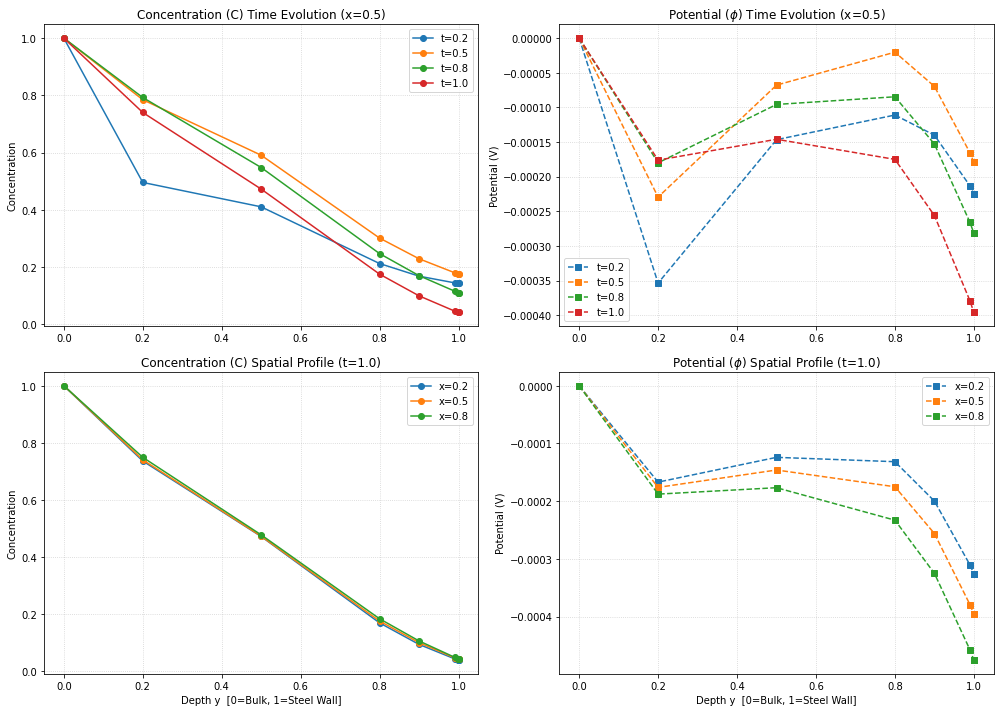

 PINN vs. FDM METRICS (t=1.0)
Concentration (C) Relative L2 Error : 5.5440e-01
Potential (phi) Relative L2 Error   : 7.3707e-01

--- Mid-Pipe Wall Point (x=0.5, y=1.0) ---
Metric     | PINN            | FDM            
---------------------------------------------
C_wall     | 4.15415764e-02  | 2.70127397e-01 
phi_wall   | -3.96174437e-04 | -1.40843516e-03
---------------------------------------------

--- Near-wall profile, mid-x (log scale) ---
y            | PINN            | FDM             | ratio     
----------------------------------------------------------
0.999962     | 4.15606499e-02  | 2.70154798e-01  | 0.2       
0.999971     | 4.15562391e-02  | 2.70148206e-01  | 0.2       
0.999979     | 4.15514112e-02  | 2.70142808e-01  | 0.2       
0.999985     | 4.15488482e-02  | 2.70138389e-01  | 0.2       
0.999990     | 4.15456891e-02  | 2.70134770e-01  | 0.2       
0.999994     | 4.15447354e-02  | 2.70131808e-01  | 0.2       
0.999997     | 4.15413380e-02  | 2.70129382e-01  | 0.2  

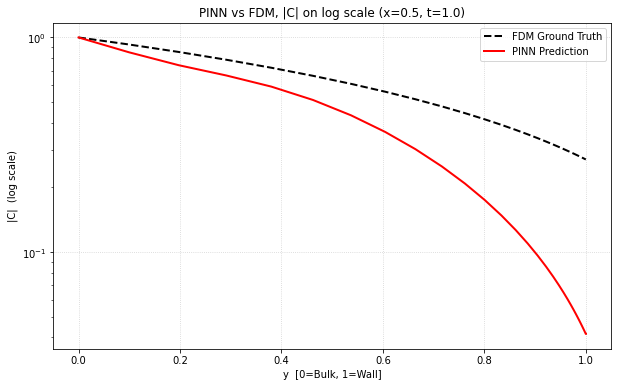

In [112]:
import matplotlib.pyplot as plt
import torch
import numpy as np


def diagnostic_boundary_scan_vmionet(model, data_tensors, device="cuda"):
    """Probes are given in PHYSICAL y (0=bulk, 1=wall) and converted to the
    model's distance coordinate d = 1 - y before inference."""
    model.eval()
    x_soil, x_fluid, x_meta, _ = [t.to(device) for t in data_tensors]
    soil_single, fluid_single, meta_single = x_soil[0:1], x_fluid[0:1], x_meta[0:1]

    # y=1.0 is the wall; extra probes packed near the wall to resolve the layer
    y_probes = [0.0, 0.2, 0.5, 0.8, 0.9, 0.99, 0.9999, 0.999999, 1.0]

    fig, axs = plt.subplots(2, 2, figsize=(14, 10))

    # ---- SWEEP 1: TIME EVOLUTION (fixed x=0.5) ----
    print(" SWEEP 1: TIME EVOLUTION (Fixed x=0.5)")
    print("=" * 50)
    for t_val in [0.2, 0.5, 0.8, 1.0]:
        print(f"\n--- TIME EVOLUTION: t={t_val}, x=0.5 ---")
        print(f"{'y-coord':<12} | {'C (Pred)':<15} | {'phi (Pred) V':<15}")
        print("-" * 48)

        C_vals, phi_vals = [], []
        with torch.no_grad():
            for y_val in y_probes:
                d_val = 1.0 - y_val                      # <-- y -> d conversion
                coord = torch.tensor([[[0.5, d_val, t_val]]],
                                     dtype=torch.float32, device=device)
                u_pred = model(soil_single, fluid_single, meta_single, coord)
                C_raw = u_pred[0, 0, 0].item()
                phi_raw = u_pred[0, 0, 1].item()
                C_vals.append(C_raw)
                phi_vals.append(phi_raw)
                print(f"{y_val:<12.6f} | {C_raw:<15.8e} | {phi_raw:<15.8e}")
        print("-" * 48)

        axs[0, 0].plot(y_probes, C_vals, marker='o', label=f"t={t_val}")
        axs[0, 1].plot(y_probes, phi_vals, marker='s', linestyle='--', label=f"t={t_val}")

    axs[0, 0].set_title('Concentration (C) Time Evolution (x=0.5)')
    axs[0, 0].set_ylabel('Concentration')
    axs[0, 1].set_title(r'Potential ($\phi$) Time Evolution (x=0.5)')
    axs[0, 1].set_ylabel('Potential (V)')

    # ---- SWEEP 2: SPATIAL DISTRIBUTION (fixed t=1.0) ----
    print(" SWEEP 2: SPATIAL DISTRIBUTION (Fixed t=1.0)")
    print("=" * 50)
    for x_val in [0.2, 0.5, 0.8]:
        print(f"\n--- SPATIAL DISTRIBUTION: t=1.0, x={x_val} ---")
        print(f"{'y-coord':<12} | {'C (Pred)':<15} | {'phi (Pred) V':<15}")
        print("-" * 48)

        C_vals, phi_vals = [], []
        with torch.no_grad():
            for y_val in y_probes:
                d_val = 1.0 - y_val                      # <-- y -> d conversion
                coord = torch.tensor([[[x_val, d_val, 1.0]]],
                                     dtype=torch.float32, device=device)
                u_pred = model(soil_single, fluid_single, meta_single, coord)
                C_raw = u_pred[0, 0, 0].item()
                phi_raw = u_pred[0, 0, 1].item()
                C_vals.append(C_raw)
                phi_vals.append(phi_raw)
                print(f"{y_val:<12.6f} | {C_raw:<15.8e} | {phi_raw:<15.8e}")
        print("-" * 48)

        axs[1, 0].plot(y_probes, C_vals, marker='o', label=f"x={x_val}")
        axs[1, 1].plot(y_probes, phi_vals, marker='s', linestyle='--', label=f"x={x_val}")

    axs[1, 0].set_title('Concentration (C) Spatial Profile (t=1.0)')
    axs[1, 0].set_xlabel('Depth y  [0=Bulk, 1=Steel Wall]')
    axs[1, 0].set_ylabel('Concentration')
    axs[1, 1].set_title(r'Potential ($\phi$) Spatial Profile (t=1.0)')
    axs[1, 1].set_xlabel('Depth y  [0=Bulk, 1=Steel Wall]')
    axs[1, 1].set_ylabel('Potential (V)')

    for ax in axs.flat:
        ax.grid(True, linestyle=':', alpha=0.6)
        ax.legend()

    plt.tight_layout()
    plt.show()


def validate_pinn_vs_fdm(model, data_tensors, device="cuda"):
    try:
        C_history_fdm = np.load("fdm_C_history_v21.npy")
        phi_fdm_field = np.load("fdm_phi_field_v21.npy")
        y_grid_fdm = np.load("fdm_y_grid_v21.npy")
    except FileNotFoundError:
        print("ERROR: FDM .npy files not found in the working directory.")
        return

    C_fdm_final = C_history_fdm[-1]
    Nx, Ny = 21, 61
    x_grid_fdm = np.linspace(0.0, 1.0, Nx)

    # FDM is in y-space; the model is in distance-space. Convert.
    d_grid_fdm = 1.0 - y_grid_fdm

    X, D = np.meshgrid(x_grid_fdm, d_grid_fdm, indexing='ij')
    T = np.ones_like(X)  # t = 1.0
    pts_3d = np.stack([X.flatten(), D.flatten(), T.flatten()], axis=-1)
    coords = torch.tensor(pts_3d, dtype=torch.float32, device=device).unsqueeze(0)

    x_soil, x_fluid, x_meta, _ = [t.to(device) for t in data_tensors]
    b_soil, b_fluid, b_meta = x_soil[0:1], x_fluid[0:1], x_meta[0:1]

    model.eval()
    with torch.no_grad():
        u_pred = model(b_soil, b_fluid, b_meta, coords)
        C_pinn_flat = u_pred[0, :, 0].cpu().numpy()
        phi_pinn_flat = u_pred[0, :, 1].cpu().numpy()

    C_pinn_final = C_pinn_flat.reshape(Nx, Ny)
    phi_pinn_field = phi_pinn_flat.reshape(Nx, Ny)

    C_err_l2 = np.linalg.norm(C_pinn_final - C_fdm_final) / (np.linalg.norm(C_fdm_final) + 1e-12)
    phi_err_l2 = np.linalg.norm(phi_pinn_field - phi_fdm_field) / (np.linalg.norm(phi_fdm_field) + 1e-12)

    print(" PINN vs. FDM METRICS (t=1.0)")
    print("=" * 50)
    print(f"Concentration (C) Relative L2 Error : {C_err_l2:.4e}")
    print(f"Potential (phi) Relative L2 Error   : {phi_err_l2:.4e}")

    mid_x_idx, wall_y_idx = Nx // 2, Ny - 1

    print("\n--- Mid-Pipe Wall Point (x=0.5, y=1.0) ---")
    print(f"{'Metric':<10} | {'PINN':<15} | {'FDM':<15}")
    print("-" * 45)
    print(f"{'C_wall':<10} | {C_pinn_final[mid_x_idx, wall_y_idx]:<15.8e} | {C_fdm_final[mid_x_idx, wall_y_idx]:<15.8e}")
    print(f"{'phi_wall':<10} | {phi_pinn_field[mid_x_idx, wall_y_idx]:<15.8e} | {phi_fdm_field[mid_x_idx, wall_y_idx]:<15.8e}")
    print("-" * 45)

    # Log-scale near-wall comparison. A LINEAR plot cannot distinguish 1e-2 from
    # 1e-6 -- that is exactly what hid the MLP test's 52x error earlier.
    print("\n--- Near-wall profile, mid-x (log scale) ---")
    print(f"{'y':<12} | {'PINN':<15} | {'FDM':<15} | {'ratio':<10}")
    print("-" * 58)
    for j in range(Ny - 8, Ny):
        p, f = C_pinn_final[mid_x_idx, j], C_fdm_final[mid_x_idx, j]
        ratio = p / f if f != 0 else float('nan')
        print(f"{y_grid_fdm[j]:<12.6f} | {p:<15.8e} | {f:<15.8e} | {ratio:<10.1f}")

    plt.figure(figsize=(10, 6))
    plt.semilogy(y_grid_fdm, np.abs(C_fdm_final[mid_x_idx, :]), 'k--',
                 label="FDM Ground Truth", linewidth=2)
    plt.semilogy(y_grid_fdm, np.abs(C_pinn_final[mid_x_idx, :]), 'r-',
                 label="PINN Prediction", linewidth=2)
    plt.title("PINN vs FDM, |C| on log scale (x=0.5, t=1.0)")
    plt.xlabel("y  [0=Bulk, 1=Wall]")
    plt.ylabel("|C|  (log scale)")
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()


diagnostic_boundary_scan_vmionet(trained_vmionet, dataset_tensors, execution_device)
validate_pinn_vs_fdm(trained_vmionet, dataset_tensors, execution_device)


In [113]:
with torch.no_grad():
    b_soil = soil_tensor[0:1].to(execution_device)
    b_fluid = fluid_tensor[0:1].to(execution_device)
    b_meta = meta_tensor[0:1].to(execution_device)
    coord_bulk = torch.tensor([[[0.5, 0.0, 1.0]]], dtype=torch.float32, device=execution_device)
    coord_wall = torch.tensor([[[0.5, 1.0, 1.0]]], dtype=torch.float32, device=execution_device)
    u_bulk = trained_vmionet(b_soil, b_fluid, b_meta, coord_bulk)
    u_wall = trained_vmionet(b_soil, b_fluid, b_meta, coord_wall)
    print(f"C at y=0: {u_bulk[0,0,0].item():.4f}")
    print(f"C at y=1: {u_wall[0,0,0].item():.4f}")

C at y=0: 0.0415
C at y=1: 1.0000


In [114]:
import torch, time

_bs = 256  # match your training batch_size
_batch = [t[:_bs].to(execution_device) for t in dataset_tensors]
_quad  = [t.to(execution_device) for t in quad_tensors]
_test  = [t.to(execution_device) for t in test_tensors]

_m = trained_vmionet  # or `model` if you haven't trained yet
_m.train()

# warmup (first call includes CUDA kernel autotuning -- don't time it)
for _ in range(3):
    r = compute_weak_loss_split(_m, _batch, _quad, _test, PHYSICS_PARAMS, N_t=3, device=execution_device)
    sum(r).backward()
    _m.zero_grad(set_to_none=True)

torch.cuda.synchronize(); t0 = time.time()
for _ in range(10):
    res_C, res_phi, bounds = compute_weak_loss_split(_m, _batch, _quad, _test, PHYSICS_PARAMS, N_t=3, device=execution_device)
torch.cuda.synchronize()
print(f"weak loss fwd only : {(time.time()-t0)/10:.4f} s")

torch.cuda.synchronize(); t0 = time.time()
for _ in range(10):
    res_C, res_phi, bounds = compute_weak_loss_split(_m, _batch, _quad, _test, PHYSICS_PARAMS, N_t=3, device=execution_device)
    (res_C + res_phi + bounds).backward()
    _m.zero_grad(set_to_none=True)
torch.cuda.synchronize()
print(f"weak loss fwd+bwd  : {(time.time()-t0)/10:.4f} s")

torch.cuda.synchronize(); t0 = time.time()
for _ in range(10):
    p = compute_essential_penalties(_m, _batch, N_samples=50, device=execution_device)
    sum(p).backward()
    _m.zero_grad(set_to_none=True)
torch.cuda.synchronize()
print(f"essential penalties: {(time.time()-t0)/10:.4f} s")

weak loss fwd only : 0.0223 s
weak loss fwd+bwd  : 0.0762 s
essential penalties: 0.0083 s


In [115]:
# =========================================================
# SUPERVISED ISOLATION TEST
# Can the exact architecture fit the verified analytic solution?
# Target in raw-output space is a CONSTANT per sample.
#
# METRIC NOTE: the headline number is WALL FLUX (dC/dy at y=1), not wall
# concentration. C_wall = 1+s is a 1-minus-1 cancellation (~6 digits
# destroyed by construction) and is physically just "essentially zero".
# The flux is O(1), well-conditioned, and is what sets corrosion current
# density -- it is the quantity the model exists to predict.
# =========================================================
import torch, torch.nn as nn, torch.optim as optim, copy

def analytic_steady_state(raw_meta, phys, n_iter=60):
    """Per-sample steady state: C = 1  s*y, phi = gamma*s*y, s from the
    self-consistent Butler-Volmer balance s = -Da*(1+s)*exp(k*eta)."""
    L  = (raw_meta[:, 0] * 0.0254).unsqueeze(1)                    # [B,1]
    Da = phys["k_rate"] * L / phys["D_global"]
    kc = phys["alpha"] * phys["F"] / (phys["R"] * phys["T"])
    sigma = 100.0 / phys["soil_resistivity_ohm_cm"]
    gamma = phys["n_electrons"] * phys["F"] * phys["D_global"] * phys["C_bulk"] / sigma
    s = -torch.ones_like(Da)
    for _ in range(n_iter):                                        # phi_wall = gamma*s
        eta = -(gamma * s) - (phys["E_eq"] - phys["E_corr"])
        A = Da * torch.exp(torch.clamp(kc * eta, max=10.0))
        s = -A / (1.0 + A)
    return s, gamma                                                # s: [B,1]

B_TEST, N_PTS, STEPS = 64, 512, 20000
dev = execution_device

soil_b, fluid_b, meta_b, raw_b = [t[:B_TEST].to(dev) for t in dataset_tensors]
s_true, gamma = analytic_steady_state(raw_b, PHYSICS_PARAMS)       # [B,1]

test_model = copy.deepcopy(model).to(dev)          # fresh weights, same architecture
opt = optim.Adam(test_model.parameters(), lr=1e-3)
sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=STEPS)

print(f"target raw_C  (per-sample constant): {(-s_true).min().item():.6f} .. {(-s_true).max().item():.6f}")
print(f"target raw_phi(per-sample constant): {(-gamma*s_true).min().item():.3e} .. {(-gamma*s_true).max().item():.3e}")
print(f"target wall flux dC/dy            : {s_true.mean().item():.6f}\n")

for step in range(1, STEPS + 1):
    x = torch.rand(N_PTS, 1, device=dev)
    d = torch.rand(N_PTS, 1, device=dev)
    t = torch.rand(N_PTS, 1, device=dev)
    coords = torch.cat([x, d, t], dim=-1).unsqueeze(0).expand(B_TEST, -1, -1)

    dm = d.squeeze(-1).unsqueeze(0)                                # [1,N]
    C_tgt   = 1.0 + (dm - 1.0) * (-s_true)                         # [B,N]
    phi_tgt =       (dm - 1.0) * (-gamma * s_true)

    u = test_model(soil_b, fluid_b, meta_b, coords)
    # ABSOLUTE MSE on C. A relative-error weighting was tried and diverged:
    # the wall denominator (~1.8e-6) gave that single point ~1e6x the weight
    # of every other, and it dominated the gradient (C-loss spiked to 3e7).
    mse_C   = torch.mean((u[..., 0] - C_tgt)**2)
    # phi is ~1e-3 vs C ~1; scale so it isn't drowned out in the sum.
    mse_phi = torch.mean(((u[..., 1] - phi_tgt) / gamma)**2)
    loss = mse_C + mse_phi

    opt.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(test_model.parameters(), max_norm=1.0)  # BEFORE step
    opt.step()
    sched.step()

    if step % 1000 == 0 or step == 1:
        print(f"step {step:5d} | total {loss.item():.4e} | C {mse_C.item():.4e} | phi {mse_phi.item():.4e}")

# ---------------- evaluation ----------------
test_model.eval()

# wall flux via autograd at d=0 (the wall). dC/dy = -dC/dd.
d_wall = torch.zeros(1, 1, device=dev, requires_grad=True)
coords_w = torch.cat([torch.full_like(d_wall, 0.5), d_wall,
                      torch.ones_like(d_wall)], dim=-1).unsqueeze(0).expand(B_TEST, -1, -1)
u_w = test_model(soil_b, fluid_b, meta_b, coords_w)
dC_dd = torch.autograd.grad(u_w[..., 0].sum(), d_wall)[0]
flux_pred = -dC_dd.item() / B_TEST   # grad accumulates over the expanded batch
flux_true = s_true.mean().item()

print(" HEADLINE METRIC -- WALL FLUX (sets corrosion current density)")
print("=" * 62)
print(f"  predicted dC/dy at wall : {flux_pred:.6f}")
print(f"  analytic  dC/dy at wall : {flux_true:.6f}")
print(f"  relative error          : {abs((flux_pred-flux_true)/flux_true)*100:.3f}%")

with torch.no_grad():
    probe_y = torch.tensor([0.0, 0.2, 0.5, 0.8, 0.99, 1.0], device=dev)
    d_probe = (1.0 - probe_y).view(-1, 1)
    coords = torch.cat([torch.full_like(d_probe, 0.5), d_probe,
                        torch.ones_like(d_probe)], dim=-1).unsqueeze(0).expand(B_TEST, -1, -1)
    u = test_model(soil_b, fluid_b, meta_b, coords)

    C_pred = u[0, :, 0]
    C_true = 1.0 + s_true[0, 0] * probe_y
    bulk = probe_y <= 0.8       # exclude the cancellation-dominated wall region
    rel_l2 = (torch.norm(C_pred[bulk] - C_true[bulk]) / torch.norm(C_true[bulk])).item()
    print(f"\n  bulk profile relative L2 (y<=0.8) : {rel_l2:.4e}")

    print(f"\n{'y':>6} {'C pred':>16} {'C true':>16} {'phi pred':>14} {'phi true':>14}")
    for i, yv in enumerate(probe_y):
        ct = (1.0 + s_true[0, 0] * yv).item()
        pt = (gamma * s_true[0, 0] * yv).item()
        print(f"{yv.item():>6.2f} {u[0,i,0].item():>16.8e} {ct:>16.8e} "
              f"{u[0,i,1].item():>14.6e} {pt:>14.6e}")
    print("\n  (C at y=1.0 is cancellation-dominated -- judge the flux above, not this value.)")

target raw_C  (per-sample constant): 0.576912 .. 0.840275
target raw_phi(per-sample constant): 1.113e-03 .. 1.621e-03
target wall flux dC/dy            : -0.764109

step     1 | total 4.2980e-01 | C 4.6068e-02 | phi 3.8373e-01
step  1000 | total 5.7335e-03 | C 9.0442e-05 | phi 5.6430e-03
step  2000 | total 7.2174e-05 | C 5.0796e-05 | phi 2.1378e-05
step  3000 | total 1.2667e-03 | C 5.2943e-04 | phi 7.3723e-04
step  4000 | total 3.3859e-05 | C 2.4810e-05 | phi 9.0483e-06
step  5000 | total 2.0251e-05 | C 1.5761e-05 | phi 4.4904e-06
step  6000 | total 1.6119e-05 | C 1.1937e-05 | phi 4.1817e-06
step  7000 | total 1.1536e-05 | C 8.1571e-06 | phi 3.3793e-06
step  8000 | total 4.0030e-05 | C 6.5701e-06 | phi 3.3460e-05
step  9000 | total 1.2833e-05 | C 6.5403e-06 | phi 6.2925e-06
step 10000 | total 8.7384e-06 | C 4.6766e-06 | phi 4.0618e-06
step 11000 | total 7.8909e-06 | C 3.5195e-06 | phi 4.3714e-06
step 12000 | total 8.4769e-06 | C 4.4444e-06 | phi 4.0326e-06
step 13000 | total 4.7415e-06

In [116]:
# =========================================================
# REFERENCE-STATE TRACE MEASUREMENT
#
# Measure Tr(K_i) at a network state that MATCHES the verified
# analytic/FDM solution (the supervised isolation model, ~0.09% wall
# flux error). This gives the gradient landscape at the true solution
# rather than at random init (init noise) or mid-training (feedback loop).
#
# IMPORTANT SCOPE: only res_C and res_phi are informative here. The
# constraint terms (bounds, ic_C, ends_*) are exactly SATISFIED at the
# solution, so their traces read ~0 -- which says nothing about how hard
# they must push when the network is AWAY from the solution. That is
# exactly when they matter (bounds had to fire when C hit 3.19 / 1.39).
# Do not derive their weights from these numbers.
# =========================================================
import torch

N_REF_BATCHES = 8   # average over more batches than the training-time update;
                    # single-batch traces varied 12-45x between seeds

ref_model = test_model            # from the supervised isolation test
ref_model.eval()

quad_dev = [t.to(execution_device) for t in quad_tensors]
test_dev = [t.to(execution_device) for t in test_tensors]
N = dataset_tensors[0].shape[0]

acc = {}
for _ in range(N_REF_BATCHES):
    idx = torch.randperm(N, device=execution_device)[:256]
    b = [t[idx] for t in dataset_tensors]
    tr = compute_traces(ref_model, b, quad_dev, test_dev, PHYSICS_PARAMS, execution_device)
    for k, v in tr.items():
        acc[k] = acc.get(k, 0.0) + v/ N_REF_BATCHES

print("\n--- Traces at the FDM-matched reference state ---")
print(f"{'term':<10} | {'Tr(K)':>12} | note")
print("-" * 58)
for k, v in sorted(acc.items(), key=lambda kv: -kv[1]):
    note = "informative" if k in ("res_C", "res_phi") else "~0 at solution; DO NOT use for weighting"
    print(f"{k:<10} | {v:>12.4e} | {note}")

if acc.get("res_phi", 0) > 0:
    ratio = acc["res_C"] / acc["res_phi"]
    print(f"\nres_C / res_phi trace ratio at the solution: {ratio:.4e}")
    print(f"  -> anchoring res_C at 1.0 gives  W_RES_PHI = {ratio:.4e}")
    print(f"     (cap it if this exceeds ~1e4; see note in the training cell)")


--- Traces at the FDM-matched reference state ---
term       |        Tr(K) | note
----------------------------------------------------------
ic_C       |   7.5745e+00 | ~0 at solution; DO NOT use for weighting
res_phi    |   9.6085e-01 | informative
res_C      |   4.5318e-02 | informative
ends_C     |   1.6249e-09 | ~0 at solution; DO NOT use for weighting
ends_phi   |   3.2962e-17 | ~0 at solution; DO NOT use for weighting
bounds     |   0.0000e+00 | ~0 at solution; DO NOT use for weighting

res_C / res_phi trace ratio at the solution: 4.7165e-02
  -> anchoring res_C at 1.0 gives  W_RES_PHI = 4.7165e-02
     (cap it if this exceeds ~1e4; see note in the training cell)


2026-08-15 16:32:26,024 | INFO | 
  split=late  W_RES_PHI=5.0
2026-08-15 16:32:26,028 | INFO | MIONet init | trunk split='late' | trunk params=83,072
2026-08-15 16:32:26,029 | INFO | Static weights: bounds=1.000e+02  ends_C=1.000e+00  ends_phi=1.000e+00  ic_C=1.000e+00  res_C=1.000e+00  res_phi=5.000e+00
2026-08-15 16:32:26,030 | INFO | Starting Factored Loop: Phase A (1000 EPs) -> Phase C (1500 EPs)...
2026-08-15 16:32:26,494 | INFO | Epoch 0001/2500 [A (Mass)] | LR: 1.00e-04 | Total: 1.052e+00 | res_C: 1.311e-01 | res_phi: 1.534e+01
2026-08-15 16:33:10,592 | INFO | Epoch 0100/2500 [A (Mass)] | LR: 9.76e-05 | Total: 2.228e-01 | res_C: 5.112e-02 | res_phi: 1.955e+03
2026-08-15 16:33:55,087 | INFO | Epoch 0200/2500 [A (Mass)] | LR: 9.05e-05 | Total: 2.746e-01 | res_C: 8.852e-02 | res_phi: 3.080e+03
2026-08-15 16:34:39,417 | INFO | Epoch 0300/2500 [A (Mass)] | LR: 7.96e-05 | Total: 9.472e-02 | res_C: 7.194e-03 | res_phi: 8.634e+03
2026-08-15 16:35:23,902 | INFO | Epoch 0400/2500 [A (Mass

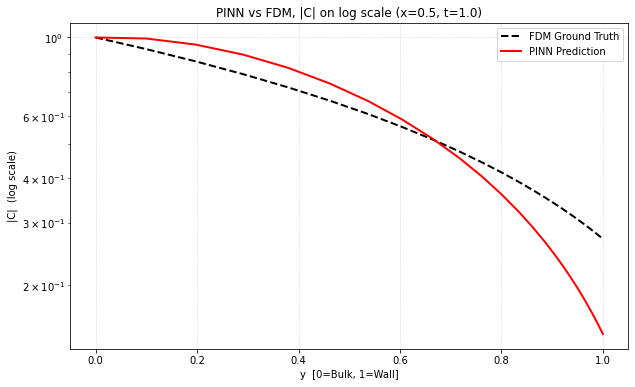


  VALIDATION: split=late  W_RES_PHI=10.0
 PINN vs. FDM METRICS (t=1.0)
Concentration (C) Relative L2 Error : 3.9171e-01
Potential (phi) Relative L2 Error   : 8.2438e-01

--- Mid-Pipe Wall Point (x=0.5, y=1.0) ---
Metric     | PINN            | FDM            
---------------------------------------------
C_wall     | 9.43950415e-02  | 2.70127397e-01 
phi_wall   | -2.60947185e-04 | -1.40843516e-03
---------------------------------------------

--- Near-wall profile, mid-x (log scale) ---
y            | PINN            | FDM             | ratio     
----------------------------------------------------------
0.999962     | 9.44280624e-02  | 2.70154798e-01  | 0.3       
0.999971     | 9.44194198e-02  | 2.70148206e-01  | 0.3       
0.999979     | 9.44135189e-02  | 2.70142808e-01  | 0.3       
0.999985     | 9.44075584e-02  | 2.70138389e-01  | 0.3       
0.999990     | 9.44036841e-02  | 2.70134770e-01  | 0.3       
0.999994     | 9.43998098e-02  | 2.70131808e-01  | 0.3       
0.999997     |

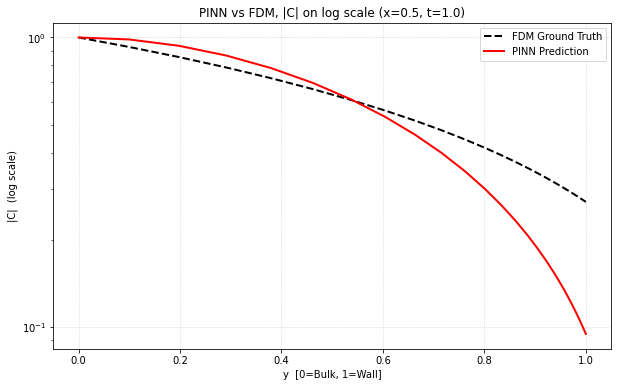


  VALIDATION: split=early  W_RES_PHI=5.0
 PINN vs. FDM METRICS (t=1.0)
Concentration (C) Relative L2 Error : 2.8268e-01
Potential (phi) Relative L2 Error   : 7.9076e-01

--- Mid-Pipe Wall Point (x=0.5, y=1.0) ---
Metric     | PINN            | FDM            
---------------------------------------------
C_wall     | 1.45192027e-01  | 2.70127397e-01 
phi_wall   | -2.97891238e-04 | -1.40843516e-03
---------------------------------------------

--- Near-wall profile, mid-x (log scale) ---
y            | PINN            | FDM             | ratio     
----------------------------------------------------------
0.999962     | 1.45222425e-01  | 2.70154798e-01  | 0.5       
0.999971     | 1.45214736e-01  | 2.70148206e-01  | 0.5       
0.999979     | 1.45209014e-01  | 2.70142808e-01  | 0.5       
0.999985     | 1.45204186e-01  | 2.70138389e-01  | 0.5       
0.999990     | 1.45199895e-01  | 2.70134770e-01  | 0.5       
0.999994     | 1.45196915e-01  | 2.70131808e-01  | 0.5       
0.999997     |

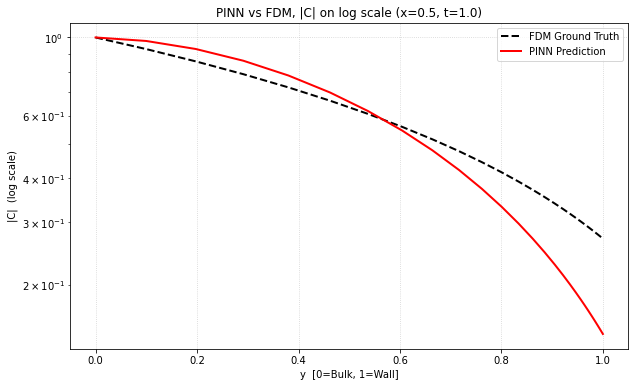


  VALIDATION: split=early  W_RES_PHI=10.0
 PINN vs. FDM METRICS (t=1.0)
Concentration (C) Relative L2 Error : 3.8331e-01
Potential (phi) Relative L2 Error   : 8.7137e-01

--- Mid-Pipe Wall Point (x=0.5, y=1.0) ---
Metric     | PINN            | FDM            
---------------------------------------------
C_wall     | 1.03912413e-01  | 2.70127397e-01 
phi_wall   | -1.79827402e-04 | -1.40843516e-03
---------------------------------------------

--- Near-wall profile, mid-x (log scale) ---
y            | PINN            | FDM             | ratio     
----------------------------------------------------------
0.999962     | 1.03936911e-01  | 2.70154798e-01  | 0.4       
0.999971     | 1.03931189e-01  | 2.70148206e-01  | 0.4       
0.999979     | 1.03925765e-01  | 2.70142808e-01  | 0.4       
0.999985     | 1.03921831e-01  | 2.70138389e-01  | 0.4       
0.999990     | 1.03918910e-01  | 2.70134770e-01  | 0.4       
0.999994     | 1.03916228e-01  | 2.70131808e-01  | 0.4       
0.999997     

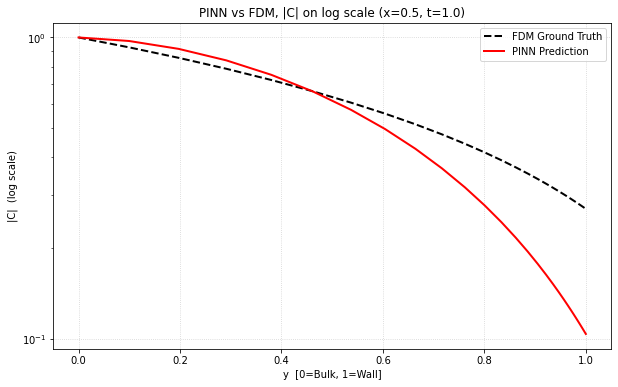

In [126]:
import torch, logging

# Full grid: 2 splits x 2 weights = 4 runs x ~25 min ~= 100 min total.
GRID = [(split, w) for split in ["late", "early"] for w in [5.0, 10.0]]

RESULTS = {}
for split, w_phi in GRID:
    logging.info(f"\n{'='*60}\n  split={split}  W_RES_PHI={w_phi}\n{'='*60}")
    torch.manual_seed(42)                      # same init stream across all arms
    m = FactoredMIONet(soil_dim=4, fluid_dim=50, meta_dim=3, split_point=split)
    RESULTS[(split, w_phi)] = train_vmionet_curriculum(
        model=m,
        data_tensors=dataset_tensors,
        quad_engine=quad_tensors,
        test_engine=test_tensors,
        phys_params=PHYSICS_PARAMS,
        epochs_a=1000, epochs_c=1500,
        lr=1e-4, batch_size=256,
        device=execution_device,
        w_res_phi=w_phi,                       # passed explicitly, not via global
    )

for (split, w), m in RESULTS.items():
    print(f"\n{'='*60}\n  VALIDATION: split={split}  W_RES_PHI={w}\n{'='*60}")
    validate_pinn_vs_fdm(m, dataset_tensors, execution_device)